# Entropy, Cross-Entropy, and Divergence

Before we can train a classifier we need a way to score a *probability distribution*. How
uncertain is a prediction? How wrong is a predicted distribution compared to the truth? These
questions are answered by **information theory**, and its answers are exactly the loss functions
Keras uses for classification. This notebook builds the three core quantities from scratch -
entropy, cross-entropy, and KL divergence - and visualizes each one so the formulas stop being
arbitrary.

## Learning objectives

- Compute the Shannon entropy of a discrete distribution and interpret it in **bits**
- Explain why entropy is maximized by the uniform distribution and zero for a certain outcome
- Show that the entropy of a *binned* continuous variable depends on the binning
- Compute cross-entropy and connect it to the `categorical_crossentropy` loss
- Decompose cross-entropy into entropy plus **KL divergence**, and explain why KL is asymmetric
- Recognize the failure mode of KL when a model assigns zero probability to a real outcome

## Background

Information theory starts from a single idea: **a surprising outcome carries more information
than an expected one.** If an event has probability $p$, its *surprisal* (or information content)
is defined as

$$I(p) = -\log_b p$$

This is the only function (up to the choice of base $b$) with the properties we want: it is zero
for a certain event ($p = 1$), it grows without bound as $p \to 0$, and the information of two
independent events adds, since $-\log(p_1 p_2) = -\log p_1 - \log p_2$.

The base $b$ sets the units:

| Base | Unit | Reading |
|---|---|---|
| $b = 2$ | **bits** | number of yes/no questions needed to identify the outcome |
| $b = e$ | nats | the natural choice for calculus; what Keras uses internally |
| $b = 10$ | bans / hartleys | rarely used |

We use $b = 2$ throughout so every number can be read as a count of yes/no questions.

Every quantity in this notebook is an **average surprisal** of one kind or another. Entropy
averages the surprisal of $P$ under $P$ itself; cross-entropy averages the surprisal assigned by
$Q$ over outcomes drawn from $P$; KL divergence measures the gap between the two.

## This notebook covers

1. Shannon entropy, with three worked examples (weighted coin, weighted die, binned normal)
2. Cross-entropy, and how it compares a true distribution to a model's predictions
3. KL divergence as the gap between cross-entropy and entropy
4. The connection back to classification losses in Keras

**Prerequisites:** none — the notebook builds every quantity from the definition of surprisal.
`U1-6_Classify-5_KerasIntro` applies the cross-entropy developed here as an actual Keras loss.

**Dataset:** none - every distribution in this notebook is constructed analytically or sampled
from `numpy.random`.

**References:** https://en.wikipedia.org/wiki/Entropy_(information_theory)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)
pd.set_option("display.precision", 4)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Shannon entropy

The **entropy** of a discrete probability distribution $P = (p_1, p_2, \ldots, p_n)$ is the
*expected surprisal* - the average number of bits needed to describe an outcome drawn from $P$:

$$H(P) = \mathbb{E}\!\left[-\log_b p_k\right] = -\sum_{k=1}^{n} p_k \log_b p_k$$

Three properties do all the work:

- $H(P) \ge 0$ always, with $H(P) = 0$ **if and only if** one outcome has probability 1. A
  certain outcome carries no information.
- $H(P)$ is **maximized by the uniform distribution**, where $p_k = 1/n$ for every $k$, giving
  $H = \log_b n$. Nothing is more uncertain than "all outcomes equally likely."
- The convention $0 \log 0 = 0$ is used, justified by $\lim_{p \to 0^+} p \log p = 0$. Impossible
  outcomes contribute nothing.

That last point is why the code below skips any $p_k = 0$ instead of calling `math.log(0)`.

In [2]:
def entropy( P, b ):
    '''
    Shannon entropy of a discrete distribution P, in units set by the log base b.

    P : sequence of probabilities that sum to 1
    b : log base -- 2 for bits, math.e for nats
    '''
    s = 0
    for p in P:
        if p > 0:                  # 0*log(0) is defined to be 0, so skip those terms
            s += -p*math.log(p,b)
        # end
    # end
    return s
# end

### 1.1 Example: the weighted coin

The simplest possible case. A coin with $P(\text{heads}) = p$ has the distribution
$P = (p,\, 1-p)$, so

$$H(p) = -p \log_2 p - (1-p)\log_2(1-p)$$

This is the **binary entropy function**. It is zero at $p = 0$ and $p = 1$ (a two-headed coin
tells you nothing when you flip it) and reaches its maximum of exactly **1 bit** at $p = 0.5$ -
one fair coin flip is, by definition, one bit of information.

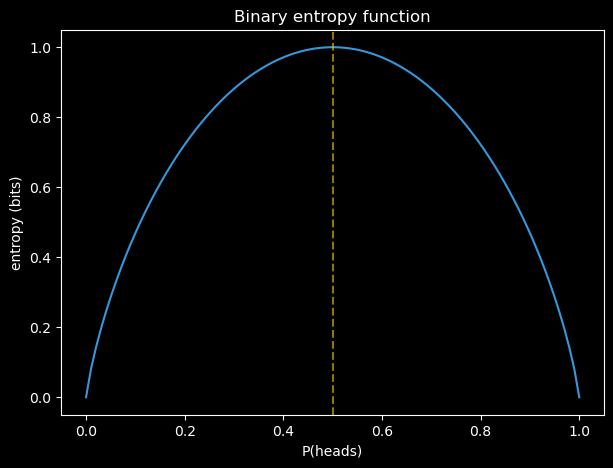

Fair coin  (p = 0.50): H = 1.0000 bits
Biased coin (p = 0.90): H = 0.4690 bits
Certain coin (p = 1.00): H = 0.0000 bits


In [3]:
# Sweep the probability of heads across its whole range.
p = np.zeros((100,2))
p[:,0] = np.linspace(0,1,100)
p[:,1] = 1 - p[:,0]

ents = [ entropy(x,2) for x in p ]

plt.figure(figsize=(7,5))
plt.plot( p[:,0], ents, color='#3498db' )
plt.axvline(0.5, color='#f1c40f', linestyle='--', alpha=0.6)
plt.xlabel('P(heads)')
plt.ylabel('entropy (bits)')
plt.title('Binary entropy function')
plt.show()

print(f'Fair coin  (p = 0.50): H = {entropy([0.5, 0.5], 2):.4f} bits')
print(f'Biased coin (p = 0.90): H = {entropy([0.9, 0.1], 2):.4f} bits')
print(f'Certain coin (p = 1.00): H = {entropy([1.0, 0.0], 2):.4f} bits')

Watching the distribution and the entropy change together makes the relationship concrete. The
left panel is the coin's distribution; the right panel marks where that coin sits on the curve
above. The bars are most lopsided exactly where the entropy is lowest.

In [4]:
import matplotlib.animation as animation

# The parameter we sweep, and the entropy at every value of it.
p_heads_sweep  = np.linspace(0, 1, 101)
coin_entropies = [ entropy([ph, 1-ph], 2) for ph in p_heads_sweep ]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def update(frame):
    ph = p_heads_sweep[frame]
    H  = coin_entropies[frame]

    # --- Left panel: the distribution at this value of p ---
    axes[0].clear()
    axes[0].bar(['Heads', 'Tails'], [ph, 1-ph], color=['#3498db', '#e74c3c'])
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel('probability')
    axes[0].set_title(f'P(heads) = {ph:.2f}')

    # --- Right panel: where that coin sits on the entropy curve ---
    axes[1].clear()
    axes[1].plot(p_heads_sweep, coin_entropies, color='gray')
    axes[1].plot(ph, H, 'o', color='#f1c40f', markersize=12)
    axes[1].axvline(ph, color='#f1c40f', linestyle='--', alpha=0.5)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.1)
    axes[1].set_xlabel('P(heads)')
    axes[1].set_ylabel('entropy (bits)')
    axes[1].set_title(f'H = {H:.3f} bits')

ani = animation.FuncAnimation(fig, update, frames=len(p_heads_sweep),
                              interval=60, blit=False)
ani.save('entropy_coin.gif', writer='pillow', fps=15)
plt.close(fig)

print('saved entropy_coin.gif')

saved entropy_coin.gif


![weighted coin entropy animation](entropy_coin.gif)

### 1.2 Example: the weighted die

Now more than two outcomes. We build a die whose face probabilities decay geometrically,
controlled by a single **exponent** $\lambda$:

$$p_k = \frac{e^{-\lambda k}}{\sum_{j=0}^{n-1} e^{-\lambda j}}, \qquad k = 0, 1, \ldots, n-1$$

The denominator is just the normalizing constant that forces $\sum_k p_k = 1$. The exponent
interpolates between the two extremes from the previous section:

- $\lambda = 0$ makes every $e^{-\lambda k} = 1$, so the die is **fair** and
  $H = \log_2 6 \approx 2.585$ bits - the maximum possible for six outcomes.
- As $\lambda \to \infty$ all the mass collapses onto face 0, and $H \to 0$.

Note that $\log_2 6$ is not an integer. Entropy is an *average* number of yes/no questions, and
averages need not be whole numbers.

lambda = 0.5
H      = 2.1572 bits
max    = 2.5850 bits  (fair die, lambda = 0)


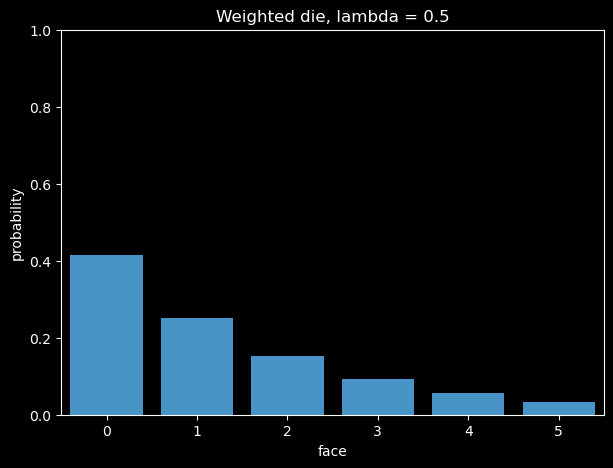

In [5]:
n = 6

# Larger lambda -> faster decay -> more lopsided die -> lower entropy.
lam = 0.5
x = np.exp( -lam * np.arange(n) )
x = x / x.sum()

print(f'lambda = {lam}')
print(f'H      = {entropy(x, 2):.4f} bits')
print(f'max    = {math.log(n, 2):.4f} bits  (fair die, lambda = 0)')

plt.figure(figsize=(7,5))
sns.barplot(x=np.arange(n), y=x, color='#3498db')
plt.ylim(0,1)
plt.xlabel('face')
plt.ylabel('probability')
plt.title(f'Weighted die, lambda = {lam}')
plt.show()

Sweeping $\lambda$ shows the die melting from fair into a near-certainty, and the entropy falling
from $\log_2 6$ toward 0 as it does.

In [6]:
# Sweep the exponent from a fair die (lambda = 0) to a nearly certain one.
lam_sweep = np.linspace(0, 3, 100)

die_dists     = []
die_entropies = []
for lam in lam_sweep:
    d = np.exp(-lam * np.arange(n))
    d = d / d.sum()
    die_dists.append(d)
    die_entropies.append(entropy(d, 2))
# end

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def update(frame):
    lam = lam_sweep[frame]
    d   = die_dists[frame]
    H   = die_entropies[frame]

    # --- Left panel: the die's distribution at this exponent ---
    axes[0].clear()
    axes[0].bar(np.arange(n), d, color='#3498db')
    axes[0].set_ylim(0, 1)
    axes[0].set_xticks(np.arange(n))
    axes[0].set_xlabel('face')
    axes[0].set_ylabel('probability')
    axes[0].set_title(f'Weighted die, lambda = {lam:.2f}')

    # --- Right panel: entropy as a function of the exponent ---
    axes[1].clear()
    axes[1].plot(lam_sweep, die_entropies, color='gray')
    axes[1].plot(lam, H, 'o', color='#f1c40f', markersize=12)
    axes[1].axhline(math.log(n,2), color='#2ecc71', linestyle='--', alpha=0.7,
                    label=f'max = log2({n}) = {math.log(n,2):.3f}')
    axes[1].set_xlim(lam_sweep[0], lam_sweep[-1])
    axes[1].set_ylim(0, math.log(n,2)*1.1)
    axes[1].set_xlabel('exponent $\\lambda$')
    axes[1].set_ylabel('entropy (bits)')
    axes[1].set_title(f'H = {H:.3f} bits')
    axes[1].legend(loc='lower left')

ani = animation.FuncAnimation(fig, update, frames=len(lam_sweep),
                              interval=60, blit=False)
ani.save('entropy_die.gif', writer='pillow', fps=15)
plt.close(fig)

print('saved entropy_die.gif')

saved entropy_die.gif


![weighted die entropy animation](entropy_die.gif)

### 1.3 Example: a binned continuous distribution

Shannon entropy is defined for *discrete* distributions, so to apply it to a continuous variable
we first have to **bin** it. Draw samples $x \sim \mathcal{N}(\mu, \sigma^2)$, chop the axis into
$m$ bins over a fixed range, and let $p_k$ be the fraction of samples landing in bin $k$:

$$p_k = \frac{\text{count in bin } k}{N}, \qquad H = -\sum_{k=1}^{m} p_k \log_2 p_k$$

This introduces a subtlety worth being explicit about. The result depends on **two** things:

1. **The spread $\sigma$.** A narrow distribution concentrates its samples in a few bins
   (low entropy); a wide one spreads them out toward uniform (high entropy). This is the part
   that reflects a genuine property of the distribution.
2. **The number of bins $m$.** More bins means more possible outcomes, and the entropy grows
   roughly like $\log_2 m$. This part is an artifact of *our* choice, not of the data.

So the entropy of a binned continuous variable is **not an intrinsic property of the density** -
change the binning and you change the number. This is exactly why the continuous analogue,
*differential entropy* $h(X) = -\int f(x)\log f(x)\,dx$, is defined by a separate formula rather
than as a limit of the discrete one.

H   = 2.4015 bits  (sigma = 2.5, 10 bins)
max = 3.3219 bits  (uniform over 10 bins)


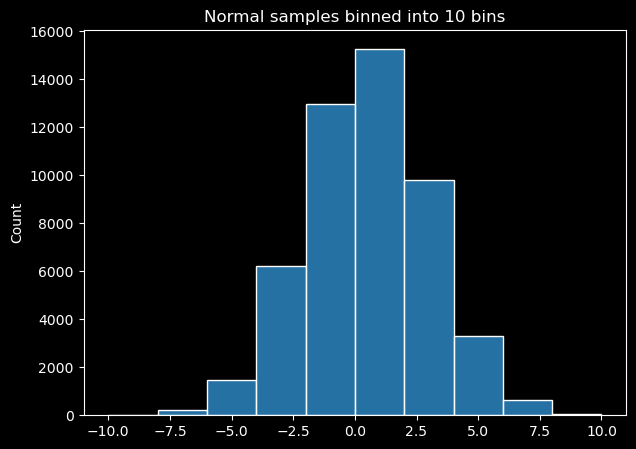

In [7]:
x = np.random.normal(0.5,2.5,50000)
xlim = [-10,10]
bins = 10

counts, _ = np.histogram(x, bins=bins, range=xlim)
counts = counts / counts.sum()

print(f'H   = {entropy(counts,2):.4f} bits  (sigma = 2.5, {bins} bins)')
print(f'max = {math.log(bins,2):.4f} bits  (uniform over {bins} bins)')

plt.figure(figsize=(7,5))
sns.histplot(x, bins=bins, binrange=xlim, color='#3498db')
plt.title(f'Normal samples binned into {bins} bins')
plt.show()

The animation below separates the two effects, one per row.

- **Top row:** the number of bins is held at 10 while $\sigma$ grows. The distribution fills more
  and more of the fixed window, approaching uniform, and the entropy climbs toward $\log_2 10$.
  This is a real change in the distribution.
- **Bottom row:** $\sigma$ is held at 2.5 while the number of bins grows. The shape on the left
  never changes - only its resolution does - yet the entropy climbs anyway, tracking the dashed
  $\log_2 m$ ceiling. This is the artifact.

Every frame reuses the **same underlying sample** (rescaled for the top row), so nothing you see
is resampling noise. Note that the bottom-left y-axis rescales each frame: with 60 bins each bar
necessarily holds less probability than with 2, and fixing the axis would flatten the shape into
invisibility.

In [8]:
# One fixed standard-normal sample, reused everywhere, so the only thing that
# changes between frames is the parameter under study.
rng = np.random.default_rng(0)
z = rng.standard_normal(50000)

xlim = (-10, 10)
bins_fixed  = 10          # held constant while sigma varies (top row)
sigma_fixed = 2.5         # held constant while the bin count varies (bottom row)

sigma_sweep = np.linspace(0.3, 5.0, 60)
bins_sweep  = np.arange(2, 62)

# --- Precompute the top row: vary sigma, bins fixed ---
sigma_dists     = []
sigma_entropies = []
for s in sigma_sweep:
    counts, edges = np.histogram(0.5 + s*z, bins=bins_fixed, range=xlim)
    P = counts / counts.sum()
    sigma_dists.append((P, edges))
    sigma_entropies.append(entropy(P, 2))
# end

# --- Precompute the bottom row: vary bin count, sigma fixed ---
x_fixed = 0.5 + sigma_fixed*z
bins_dists     = []
bins_entropies = []
for m in bins_sweep:
    counts, edges = np.histogram(x_fixed, bins=m, range=xlim)
    P = counts / counts.sum()
    bins_dists.append((P, edges))
    bins_entropies.append(entropy(P, 2))
# end

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

def update(frame):
    # ================= TOP ROW: varying sigma =================
    s = sigma_sweep[frame]
    P, edges = sigma_dists[frame]
    H = sigma_entropies[frame]

    centers = (edges[:-1] + edges[1:]) / 2
    width   = edges[1] - edges[0]

    axes[0,0].clear()
    axes[0,0].bar(centers, P, width=width*0.95, color='#3498db')
    axes[0,0].set_xlim(xlim)
    axes[0,0].set_ylim(0, 1)
    axes[0,0].set_ylabel('probability')
    axes[0,0].set_title(f'sigma = {s:.2f}   ({bins_fixed} bins)')

    axes[0,1].clear()
    axes[0,1].plot(sigma_sweep, sigma_entropies, color='gray')
    axes[0,1].plot(s, H, 'o', color='#f1c40f', markersize=12)
    axes[0,1].axhline(math.log(bins_fixed,2), color='#2ecc71', linestyle='--', alpha=0.7,
                      label=f'log2({bins_fixed}) = {math.log(bins_fixed,2):.2f}')
    axes[0,1].set_xlim(sigma_sweep[0], sigma_sweep[-1])
    axes[0,1].set_ylim(0, math.log(bins_fixed,2)*1.15)
    axes[0,1].set_xlabel('standard deviation $\\sigma$')
    axes[0,1].set_ylabel('entropy (bits)')
    axes[0,1].set_title(f'H = {H:.3f} bits')
    axes[0,1].legend(loc='lower right')

    # ================= BOTTOM ROW: varying bin count =================
    m = bins_sweep[frame]
    P, edges = bins_dists[frame]
    H = bins_entropies[frame]

    centers = (edges[:-1] + edges[1:]) / 2
    width   = edges[1] - edges[0]

    axes[1,0].clear()
    axes[1,0].bar(centers, P, width=width*0.95, color='#e74c3c')
    axes[1,0].set_xlim(xlim)
    axes[1,0].set_ylim(0, P.max()*1.3)     # rescaled each frame -- see the note above
    axes[1,0].set_xlabel('x')
    axes[1,0].set_ylabel('probability')
    axes[1,0].set_title(f'{m} bins   (sigma = {sigma_fixed})')

    axes[1,1].clear()
    axes[1,1].plot(bins_sweep, bins_entropies, color='gray')
    axes[1,1].plot(bins_sweep, np.log2(bins_sweep), color='#2ecc71', linestyle='--',
                   alpha=0.7, label='log2(bins)')
    axes[1,1].plot(m, H, 'o', color='#f1c40f', markersize=12)
    axes[1,1].set_xlim(bins_sweep[0], bins_sweep[-1])
    axes[1,1].set_ylim(0, np.log2(bins_sweep[-1])*1.15)
    axes[1,1].set_xlabel('number of bins')
    axes[1,1].set_ylabel('entropy (bits)')
    axes[1,1].set_title(f'H = {H:.3f} bits')
    axes[1,1].legend(loc='lower right')

    plt.tight_layout()

ani = animation.FuncAnimation(fig, update, frames=len(sigma_sweep),
                              interval=80, blit=False)
ani.save('entropy_normal.gif', writer='pillow', fps=12)
plt.close(fig)

print('saved entropy_normal.gif')

saved entropy_normal.gif


![binned normal entropy animation](entropy_normal.gif)

### 1.4 Test: entropy against a known reference

Two checks. First, the analytic maximum: a uniform distribution over $n$ outcomes must give
exactly $\log_2 n$. Second, `scipy.stats.entropy` computes the same quantity, so our
hand-written loop should agree with it to floating-point precision.

In [9]:
from scipy.stats import entropy as scipy_entropy

for n_out in [2, 4, 6, 10]:
    uniform = np.ones(n_out) / n_out
    print(f'n = {n_out:2d}:  H = {entropy(uniform, 2):.6f}   log2(n) = {math.log(n_out,2):.6f}')
# end

print()

test_dists = [
    np.array([0.5, 0.5]),
    np.array([0.9, 0.1]),
    np.array([0.4, 0.3, 0.2, 0.1]),
    np.array([1.0, 0.0, 0.0]),          # exercises the 0*log(0) = 0 convention
]
for P in test_dists:
    ours  = entropy(P, 2)
    theirs = scipy_entropy(P, base=2)
    print(f'P = {str(P):28s}  ours = {ours:.6f}  scipy = {theirs:.6f}  match = {np.isclose(ours, theirs)}')
# end

n =  2:  H = 1.000000   log2(n) = 1.000000
n =  4:  H = 2.000000   log2(n) = 2.000000
n =  6:  H = 2.584963   log2(n) = 2.584963
n = 10:  H = 3.321928   log2(n) = 3.321928

P = [0.5 0.5]                     ours = 1.000000  scipy = 1.000000  match = True
P = [0.9 0.1]                     ours = 0.468996  scipy = 0.468996  match = True
P = [0.4 0.3 0.2 0.1]             ours = 1.846439  scipy = 1.846439  match = True
P = [1. 0. 0.]                    ours = 0.000000  scipy = 0.000000  match = True


## 2. Cross-entropy

Entropy scores a single distribution. **Cross-entropy** scores a *pair*: it measures the cost of
describing outcomes that actually come from $P$ using a code built for $Q$. We write it
$H_Q(P)$ - the entropy *of* $P$, measured *under* $Q$:

$$H_Q(P) = \mathbb{E}\!\left[-\log_b q_k\right] = -\sum_{k=1}^{n} p_k \log_b q_k$$

Compare this to entropy, $H(P) = -\sum_k p_k \log_b p_k$. The weights out front are still the
**true** probabilities $p_k$ - reality decides how often each outcome happens - but the surprisal
inside the log now comes from the **model's** probabilities $q_k$. You are charged $-\log q_k$
bits every time outcome $k$ occurs, and it occurs at rate $p_k$. Note that the expectation is
still taken over $P$; only the code being charged for has changed. Setting $Q = P$ recovers
ordinary entropy, $H_P(P) = H(P)$.

Two consequences follow immediately, and they are the entire reason this is a loss function:

- $H_Q(P) \ge H(P)$ for every $Q$. Using the wrong distribution can never be cheaper than using
  the right one. (This is **Gibbs' inequality**.)
- Equality holds **only** when $Q = P$. So minimizing $H_Q(P)$ over $Q$ drives $Q$ toward $P$.

Cross-entropy is also **asymmetric**: $H_Q(P) \ne H_P(Q)$ in general. And note the danger in
the formula - if $q_k = 0$ for some outcome with $p_k > 0$, then $-\log q_k = \infty$ and the
cross-entropy is infinite. A model that declares an outcome impossible, and is then shown that
outcome, is infinitely surprised. This is why implementations clip predicted probabilities away
from 0.

In [10]:
def cross_entropy( P, Q, b ):
    '''
    Cross-entropy H_Q(P): the average cost of encoding outcomes from P using Q.

    P : the true distribution (supplies the weights)
    Q : the model's distribution (supplies the surprisals)
    b : log base -- 2 for bits
    '''
    s = 0
    for i in range(len(P)):
        if Q[i] > 0:               # a zero in Q where P is positive means infinite cost
            s += -P[i]*math.log(Q[i],b)
        # end
    # end
    return s
# end

### 2.1 Example: true distribution vs. model prediction

This is the setup we will meet constantly in the rest of the unit. There are four classes;
$p$ is how often each class actually occurs, and $q$ is what a model predicts. Plotting them as
a grouped bar chart - `seaborn`'s `hue` argument puts the two distributions side by side within
each class - makes the disagreement visible.

H(p)    = 1.7427 bits   (the irreducible uncertainty in p)
H_q(p)  = 1.7757 bits   (the cost of using q to describe p)
gap     = 0.0329 bits   (what the model wastes)


,class,probability,distribution
0,A,0.50,p (true)
1,B,0.25,p (true)
2,C,0.15,p (true)
3,D,0.10,p (true)
4,A,0.40,q (model)
5,B,0.30,q (model)
6,C,0.20,q (model)
7,D,0.10,q (model)


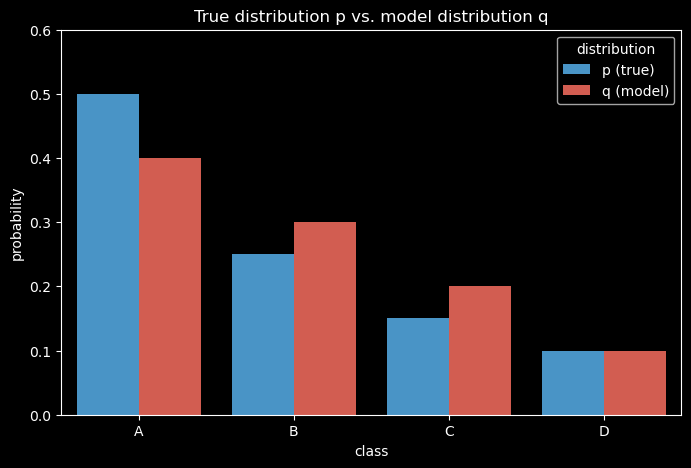

In [11]:
class_names = ['A', 'B', 'C', 'D']
n = len(class_names)

p = np.array([0.50, 0.25, 0.15, 0.10])    # the true distribution
q = np.array([0.40, 0.30, 0.20, 0.10])    # the model's predicted distribution

print(f'H(p)    = {entropy(p, 2):.4f} bits   (the irreducible uncertainty in p)')
print(f'H_q(p)  = {cross_entropy(p, q, 2):.4f} bits   (the cost of using q to describe p)')
print(f'gap     = {cross_entropy(p, q, 2) - entropy(p, 2):.4f} bits   (what the model wastes)')

# A tidy (long-form) frame is what seaborn's hue argument expects: one row per
# bar, with a column naming which distribution that bar belongs to.
df = pd.DataFrame({
    'class':        np.tile(class_names, 2),
    'probability':  np.concatenate([p, q]),
    'distribution': ['p (true)']*n + ['q (model)']*n,
})
display(df)

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='class', y='probability', hue='distribution',
            palette=['#3498db', '#e74c3c'])
plt.ylim(0, 0.6)
plt.title('True distribution p vs. model distribution q')
plt.show()

### 2.2 Watching cross-entropy grow

To see how cross-entropy responds as a model gets worse, slide $q$ along a straight line away
from the truth. Let $e$ put all its mass on class D - the *least* likely class under $p$ - and
define

$$q_t = (1-t)\,p + t\,e, \qquad t \in [0, 1]$$

At $t = 0$ the model is perfect; at $t = 1$ it is maximally, confidently wrong. The left panel
shows $p$ and $q_t$ side by side as the model drifts; the right panel tracks $H_{q_t}(p)$.

The single most important thing to notice is where the curve **starts**. At $t = 0$ the model is
exactly right, and yet the cross-entropy is not zero - it bottoms out at $H(p) = 1.743$ bits, the
green dashed line. That floor is the uncertainty inherent in $p$ itself, and no model can get
below it. Cross-entropy is not a measure of error; it is a total cost, of which the error is only
the part above the floor.

In [12]:
e = np.array([0.0, 0.0, 0.0, 1.0])        # all mass on the least likely class

# Stop just short of t = 1: at t = 1 exactly, three entries of q are zero and
# the cross-entropy is infinite.
t_sweep = np.linspace(0, 0.99, 100)

q_path  = []
ce_vals = []
for t in t_sweep:
    q_t = (1 - t)*p + t*e
    q_path.append(q_t)
    ce_vals.append(cross_entropy(p, q_t, 2))
# end

H_p = entropy(p, 2)
bar_x = np.arange(n)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def update(frame):
    t   = t_sweep[frame]
    q_t = q_path[frame]
    ce  = ce_vals[frame]

    # --- Left panel: p and q_t side by side, the seaborn 'hue' layout by hand ---
    axes[0].clear()
    axes[0].bar(bar_x - 0.2, p,   width=0.4, color='#3498db', label='p (true)')
    axes[0].bar(bar_x + 0.2, q_t, width=0.4, color='#e74c3c', label='$q_t$ (model)')
    axes[0].set_xticks(bar_x)
    axes[0].set_xticklabels(class_names)
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel('class')
    axes[0].set_ylabel('probability')
    axes[0].set_title(f't = {t:.2f}')
    axes[0].legend(loc='upper right')

    # --- Right panel: cross-entropy along the path, with the H(p) floor ---
    axes[1].clear()
    axes[1].plot(t_sweep, ce_vals, color='gray')
    axes[1].plot(t, ce, 'o', color='#f1c40f', markersize=12)
    axes[1].axhline(H_p, color='#2ecc71', linestyle='--', alpha=0.8,
                    label=f'floor = H(p) = {H_p:.3f}')
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, max(ce_vals)*1.1)
    axes[1].set_xlabel('t   (0 = perfect model, 1 = confidently wrong)')
    axes[1].set_ylabel('bits')
    axes[1].set_title(f'$H_{{q_t}}(p)$ = {ce:.3f} bits')
    axes[1].legend(loc='upper left')

ani = animation.FuncAnimation(fig, update, frames=len(t_sweep),
                              interval=60, blit=False)
ani.save('cross_entropy.gif', writer='pillow', fps=15)
plt.close(fig)

print('saved cross_entropy.gif')

saved cross_entropy.gif


![cross-entropy animation](cross_entropy.gif)

### 2.3 Test: cross-entropy against itself

Two sanity checks that follow directly from the definitions. Setting $Q = P$ must reproduce the
entropy exactly, since the formula becomes $-\sum p_k \log p_k$. And Gibbs' inequality says no
other $Q$ can beat it, so a handful of random alternatives should all score higher.

In [13]:
print(f'H_p(p) = {cross_entropy(p, p, 2):.6f}')
print(f'H(p)   = {entropy(p, 2):.6f}')
print(f'equal  = {np.isclose(cross_entropy(p, p, 2), entropy(p, 2))}')
print()

# Gibbs' inequality: every other distribution costs more than p itself.
rng = np.random.default_rng(1)
print('random q:            H_q(p)      >= H(p)?')
for i in range(5):
    q_rand = rng.random(n)
    q_rand = q_rand / q_rand.sum()
    ce = cross_entropy(p, q_rand, 2)
    print(f'  {np.round(q_rand,3)}   {ce:.4f}      {ce >= entropy(p, 2)}')
# end

H_p(p) = 1.742738
H(p)   = 1.742738
equal  = True

random q:            H_q(p)      >= H(p)?
  [0.2   0.372 0.056 0.371]   2.2816      True
  [0.158 0.215 0.42  0.207]   2.3002      True
  [0.294 0.015 0.403 0.288]   2.7799      True
  [0.176 0.421 0.162 0.242]   2.1652      True
  [0.134 0.402 0.203 0.262]   2.3192      True


## 3. Kullback-Leibler divergence

Cross-entropy mixes together two different things: the uncertainty that is inherent in $P$, and
the extra cost incurred by using the wrong distribution. **KL divergence** isolates the second
part by simply subtracting the first:

$$D_{\mathrm{KL}}(P \parallel Q) = H_Q(P) - H(P)$$

Expanding both terms and combining the logs gives the more common form:

$$D_{\mathrm{KL}}(P \parallel Q) = -\sum_k p_k \log_b q_k + \sum_k p_k \log_b p_k
= \sum_{k=1}^{n} p_k \log_b \frac{p_k}{q_k}$$

Read it as the average, over outcomes drawn from $P$, of how many bits the model *wastes* on
each one. Its properties:

- $D_{\mathrm{KL}}(P \parallel Q) \ge 0$, with equality **if and only if** $P = Q$. This is
  Gibbs' inequality restated, and it is what makes KL a sensible "distance from the truth."
- It is **not symmetric**: $D_{\mathrm{KL}}(P \parallel Q) \ne D_{\mathrm{KL}}(Q \parallel P)$.
  So it is *not* a distance metric, despite being used like one. The order of the arguments
  encodes which distribution is the truth and which is the approximation.
- It is **unbounded**. If $q_k = 0$ anywhere that $p_k > 0$, the divergence is infinite.

The relationship $H_Q(P) = H(P) + D_{\mathrm{KL}}(P \parallel Q)$ is worth committing to memory:
since $H(P)$ is a property of the data and does not depend on the model, **minimizing
cross-entropy over $Q$ is exactly the same as minimizing KL divergence.** Training a classifier
on cross-entropy loss is training it to make its predicted distribution match the truth.

In [14]:
def kl_divergence( P, Q, b ):
    '''
    KL divergence D(P || Q): the extra cost of using Q when the truth is P.

    Equivalent to cross_entropy(P, Q, b) - entropy(P, b).
    '''
    s = 0
    for i in range(len(P)):
        if P[i] > 0 and Q[i] > 0:  # P[i] = 0 contributes nothing; Q[i] = 0 is infinite
            s += P[i]*math.log(P[i]/Q[i],b)
        # end
    # end
    return s
# end

### 3.1 Example: the same p and q

Using the four-class example from section 2, we can confirm the decomposition numerically and
then swap the arguments to see the asymmetry.

In [15]:
print(f'H(p)            = {entropy(p, 2):.4f} bits')
print(f'H_q(p)          = {cross_entropy(p, q, 2):.4f} bits')
print(f'D_KL(p || q)    = {kl_divergence(p, q, 2):.4f} bits')
print(f'H_q(p) - H(p)   = {cross_entropy(p, q, 2) - entropy(p, 2):.4f} bits   <- same number')
print()
print('Asymmetry:')
print(f'D_KL(p || q)    = {kl_divergence(p, q, 2):.4f} bits')
print(f'D_KL(q || p)    = {kl_divergence(q, p, 2):.4f} bits   <- different')
print()
print(f'D_KL(p || p)    = {kl_divergence(p, p, 2):.4f} bits   <- zero, as required')

H(p)            = 1.7427 bits
H_q(p)          = 1.7757 bits
D_KL(p || q)    = 0.0329 bits
H_q(p) - H(p)   = 0.0329 bits   <- same number

Asymmetry:
D_KL(p || q)    = 0.0329 bits
D_KL(q || p)    = 0.0331 bits   <- different

D_KL(p || p)    = 0.0000 bits   <- zero, as required


### 3.2 Watching the divergence grow

Now run the same $q_t$ path from section 2.2 again, this time tracking KL. The two panels make
the decomposition $D_{\mathrm{KL}}(p \parallel q_t) = H_{q_t}(p) - H(p)$ visible as a *distance*
on the plot:

- The **middle panel** carries over the cross-entropy curve with the $H(p)$ floor, and shades the
  vertical gap between them. That shaded height **is** the KL divergence.
- The **right panel** plots that height on its own, starting from exactly zero at $t = 0$.

Where cross-entropy started at 1.743 bits, KL starts at 0. Subtracting $H(p)$ removed the part of
the cost that belongs to the data rather than to the model - which is why KL, not cross-entropy,
is the honest answer to "how wrong is this model?"

In [16]:
kl_vals = []
for t in t_sweep:
    q_t = (1 - t)*p + t*e
    kl_vals.append(kl_divergence(p, q_t, 2))
# end

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def update(frame):
    t   = t_sweep[frame]
    q_t = q_path[frame]
    ce  = ce_vals[frame]
    kl  = kl_vals[frame]

    # --- Left panel: p and q_t side by side ---
    axes[0].clear()
    axes[0].bar(bar_x - 0.2, p,   width=0.4, color='#3498db', label='p (true)')
    axes[0].bar(bar_x + 0.2, q_t, width=0.4, color='#e74c3c', label='$q_t$ (model)')
    axes[0].set_xticks(bar_x)
    axes[0].set_xticklabels(class_names)
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel('class')
    axes[0].set_ylabel('probability')
    axes[0].set_title(f't = {t:.2f}')
    axes[0].legend(loc='upper right')

    # --- Middle panel: KL shown as the gap between cross-entropy and H(p) ---
    axes[1].clear()
    axes[1].plot(t_sweep, ce_vals, color='#3498db', label='$H_{q_t}(p)$')
    axes[1].axhline(H_p, color='#2ecc71', linestyle='--', alpha=0.8,
                    label=f'H(p) = {H_p:.3f}')
    # The shaded band between the floor and the curve, up to the current t, is the divergence.
    shown = t_sweep <= t
    axes[1].fill_between(t_sweep[shown], H_p, np.array(ce_vals)[shown],
                         color='#e74c3c', alpha=0.35)
    axes[1].plot([t, t], [H_p, ce], color='#e74c3c', linewidth=3)
    axes[1].plot(t, ce, 'o', color='#f1c40f', markersize=12)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, max(ce_vals)*1.1)
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('bits')
    axes[1].set_title(f'gap = {kl:.3f} bits')
    axes[1].legend(loc='upper left')

    # --- Right panel: that gap plotted as its own curve ---
    axes[2].clear()
    axes[2].plot(t_sweep, kl_vals, color='#e74c3c')
    axes[2].plot(t, kl, 'o', color='#f1c40f', markersize=12)
    axes[2].axhline(0, color='#2ecc71', linestyle='--', alpha=0.8, label='floor = 0')
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, max(kl_vals)*1.1)
    axes[2].set_xlabel('t')
    axes[2].set_ylabel('bits')
    axes[2].set_title(f'$D_{{KL}}(p \\parallel q_t)$ = {kl:.3f} bits')
    axes[2].legend(loc='upper left')

    plt.tight_layout()

ani = animation.FuncAnimation(fig, update, frames=len(t_sweep),
                              interval=60, blit=False)
ani.save('kl_divergence.gif', writer='pillow', fps=15)
plt.close(fig)

print('saved kl_divergence.gif')

saved kl_divergence.gif


![KL divergence animation](kl_divergence.gif)

The same sweep as a static figure, with the gap between the two curves shaded. That gap is
constant in *meaning* but not in size: it is the entire KL divergence, and it grows without bound
while $H(p)$ stays fixed.

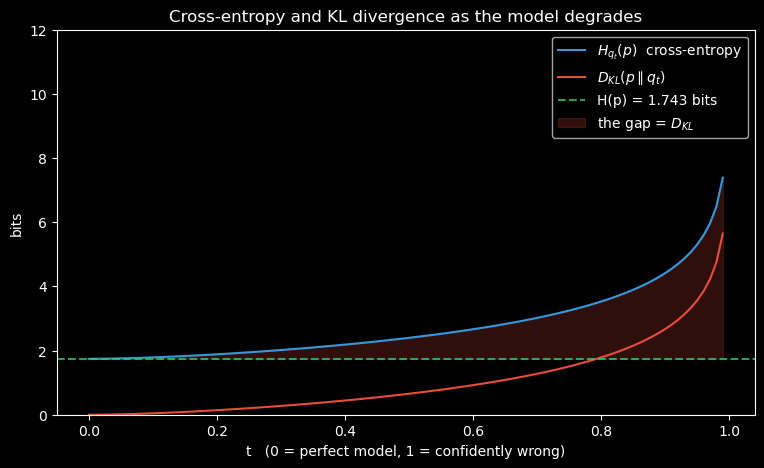

At t = 0.00:  H_q(p) =   1.7427   KL = 0.0000
At t = 0.99:  H_q(p) =   7.3913   KL = 5.6486
The shaded height is always exactly H_q(p) - H(p).


In [17]:
plt.figure(figsize=(9,5))
plt.plot(t_sweep, ce_vals, color='#3498db', label='$H_{q_t}(p)$  cross-entropy')
plt.plot(t_sweep, kl_vals, color='#e74c3c', label='$D_{KL}(p \\parallel q_t)$')
plt.axhline(H_p, color='#2ecc71', linestyle='--', alpha=0.8,
            label=f'H(p) = {H_p:.3f} bits')
plt.fill_between(t_sweep, H_p, ce_vals, color='#e74c3c', alpha=0.2,
                 label='the gap = $D_{KL}$')
plt.xlabel('t   (0 = perfect model, 1 = confidently wrong)')
plt.ylabel('bits')
plt.ylim(0, 12)
plt.title('Cross-entropy and KL divergence as the model degrades')
plt.legend()
plt.show()

print(f'At t = 0.00:  H_q(p) = {ce_vals[0]:8.4f}   KL = {kl_vals[0]:.4f}')
print(f'At t = 0.99:  H_q(p) = {ce_vals[-1]:8.4f}   KL = {kl_vals[-1]:.4f}')
print('The shaded height is always exactly H_q(p) - H(p).')

A table of the same quantities at a few points along the sweep:

In [18]:
rows = []
for t in [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]:
    q_t = (1 - t)*p + t*e
    rows.append({
        't':            t,
        'H_q(p)':       cross_entropy(p, q_t, 2),
        'D_KL(p||q_t)': kl_divergence(p, q_t, 2),
    })
# end

summary = pd.DataFrame(rows)
display(summary)

,t,H_q(p),D_KL(p||q_t)
0,0.00,1.7427,0.0000
1,0.10,1.7869,0.0442
2,0.25,1.9462,0.2035
3,0.50,2.3968,0.6541
4,0.75,3.2473,1.5046
5,0.90,4.4139,2.6711
6,0.99,7.3913,5.6486


### 3.3 The zero-probability trap

Both `cross_entropy` and `kl_divergence` above guard against $q_k = 0$ by skipping those terms.
That keeps the code from crashing on `math.log(0)`, but it quietly returns a **finite number in a
case where the true answer is $+\infty$**. Two distributions with completely disjoint support are
infinitely far apart under KL, and our functions will happily report 0.0 instead.

In [19]:
far_a = np.array([0.5, 0.5, 0.0, 0.0])
far_b = np.array([0.0, 0.0, 0.5, 0.5])

print('Two distributions with no overlap at all:')
print(f'  a = {far_a}')
print(f'  b = {far_b}')
print()
print(f'D_KL(a || b) = {kl_divergence(far_a, far_b, 2):.4f} bits   <- WRONG, the answer is infinite')
print(f'H_b(a)       = {cross_entropy(far_a, far_b, 2):.4f} bits   <- also wrong, for the same reason')
print()

# What the guard is hiding: every term of the sum is -0.5 * log2(0) = +inf.
eps_values = [1e-2, 1e-4, 1e-8, 1e-16]
print('Clipping q away from zero shows the divergence blowing up:')
for eps in eps_values:
    b_clipped = np.clip(far_b, eps, None)
    b_clipped = b_clipped / b_clipped.sum()
    print(f'  eps = {eps:.0e}:  D_KL(a || b) = {kl_divergence(far_a, b_clipped, 2):8.4f} bits')
# end

Two distributions with no overlap at all:
  a = [0.5 0.5 0.  0. ]
  b = [0.  0.  0.5 0.5]

D_KL(a || b) = 0.0000 bits   <- WRONG, the answer is infinite
H_b(a)       = 0.0000 bits   <- also wrong, for the same reason

Clipping q away from zero shows the divergence blowing up:
  eps = 1e-02:  D_KL(a || b) =   5.6724 bits
  eps = 1e-04:  D_KL(a || b) =  12.2880 bits
  eps = 1e-08:  D_KL(a || b) =  25.5754 bits
  eps = 1e-16:  D_KL(a || b) =  52.1508 bits


This is exactly why real implementations clip predicted probabilities away from zero rather than
skipping them. Keras applies a small epsilon inside its cross-entropy losses for precisely this
reason - an unlucky softmax output of 0.0 would otherwise make the loss, and every gradient
downstream of it, infinite.

### 3.4 Test: KL against `scipy`

`scipy.stats.entropy` doubles as a KL divergence when given two arguments, so it validates both
our `kl_divergence` and (via the decomposition) our `cross_entropy`.

In [20]:
checks = [
    ('H(p)',        entropy(p, 2),               scipy_entropy(p, base=2)),
    ('H(q)',        entropy(q, 2),               scipy_entropy(q, base=2)),
    ('D_KL(p||q)',  kl_divergence(p, q, 2),      scipy_entropy(p, q, base=2)),
    ('D_KL(q||p)',  kl_divergence(q, p, 2),      scipy_entropy(q, p, base=2)),
    # The decomposition: cross-entropy minus entropy must equal KL.
    ('H_q(p)-H(p)', cross_entropy(p, q, 2) - entropy(p, 2), scipy_entropy(p, q, base=2)),
]

for name, ours, theirs in checks:
    print(f'{name:14s}  ours = {ours:.8f}   scipy = {theirs:.8f}   match = {np.isclose(ours, theirs)}')
# end

H(p)            ours = 1.74273765   scipy = 1.74273765   match = True
H(q)            ours = 1.84643934   scipy = 1.84643934   match = True
D_KL(p||q)      ours = 0.03294982   scipy = 0.03294982   match = True
D_KL(q||p)      ours = 0.03314658   scipy = 0.03314658   match = True
H_q(p)-H(p)     ours = 0.03294982   scipy = 0.03294982   match = True


## 4. Why this matters for classification

Everything above becomes concrete the moment we train a classifier. For a single training example
with true label $y$, the "true distribution" $P$ is a **one-hot** vector: probability 1 on the
correct class and 0 everywhere else. The model outputs a softmax distribution $Q = \hat{p}$.

Substituting a one-hot $P$ into the cross-entropy formula collapses the sum to a single term,
because every $p_k$ is zero except $p_y = 1$:

$$H_Q(P) = -\sum_k p_k \log q_k = -\log \hat{p}_y$$

And since a one-hot distribution has $H(P) = 0$ - the label is certain - the decomposition
$H_Q(P) = H(P) + D_{\mathrm{KL}}(P \parallel Q)$ tells us that for one-hot labels,
**cross-entropy and KL divergence are the same number.**

Averaging over a training set of $N$ examples gives exactly the loss Keras minimizes:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log \hat{p}^{(i)}_{y_i}$$

which is `sparse_categorical_crossentropy` when the labels are integers, and
`categorical_crossentropy` when they are one-hot encoded. The two compute the same quantity and
differ only in how the labels arrive.

In [21]:
# One training example: the true class is B (index 1), and the model gives it 0.30.
one_hot = np.array([0.0, 1.0, 0.0, 0.0])
q_pred  = np.array([0.40, 0.30, 0.20, 0.10])

print(f'H(one_hot)              = {entropy(one_hot, 2):.4f} bits   <- a known label is certain')
print(f'H_q(one_hot)            = {cross_entropy(one_hot, q_pred, 2):.4f} bits')
print(f'D_KL(one_hot || q_pred) = {kl_divergence(one_hot, q_pred, 2):.4f} bits   <- identical')
print(f'-log2(q_pred[1])        = {-math.log(q_pred[1], 2):.4f} bits   <- and it is just this')
print()

# The loss falls as the model becomes more confident in the correct class.
print('confidence in true class -> loss (bits)')
for conf in [0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    print(f'   {conf:.2f}  ->  {-math.log(conf, 2):.4f}')
# end

H(one_hot)              = 0.0000 bits   <- a known label is certain
H_q(one_hot)            = 1.7370 bits
D_KL(one_hot || q_pred) = 1.7370 bits   <- identical
-log2(q_pred[1])        = 1.7370 bits   <- and it is just this

confidence in true class -> loss (bits)
   0.05  ->  4.3219
   0.10  ->  3.3219
   0.30  ->  1.7370
   0.50  ->  1.0000
   0.70  ->  0.5146
   0.90  ->  0.1520
   0.99  ->  0.0145


That last table is the shape of the loss surface a classifier descends: the penalty for being
confidently wrong grows without bound, while the reward for being *more* confident when already
correct flattens out. Cross-entropy punishes overconfident mistakes far more than it rewards
extra certainty - which is exactly the incentive we want.

## 5. Review

| Quantity | Formula (base $b$) | Symmetric? | Range |
|---|---|---|---|
| Entropy | $H(P) = -\sum_k p_k \log_b p_k$ | n/a | $[0,\ \log_b n]$ |
| Cross-entropy | $H_Q(P) = -\sum_k p_k \log_b q_k$ | no | $[H(P),\ \infty)$ |
| KL divergence | $D_{\mathrm{KL}}(P \parallel Q) = \sum_k p_k \log_b \frac{p_k}{q_k}$ | no | $[0,\ \infty)$ |

- **Entropy is average surprisal.** It is 0 for a certain outcome and maximized at $\log_b n$ by
  the uniform distribution. In base 2 the units are bits: the number of yes/no questions needed
  on average to pin down the outcome.
- The coin and die examples show the same story with different numbers of outcomes: the more
  lopsided the distribution, the lower the entropy.
- **Binning a continuous variable makes its entropy depend on the binning.** Entropy rises with
  $\sigma$ (a real property of the distribution) but also with the number of bins (an artifact of
  our choice, growing like $\log_2 m$). Differential entropy exists precisely because of this.
- **Cross-entropy $H_Q(P) \ge H(P)$**, always, with equality only when $Q = P$. That inequality
  is what makes it usable as a loss. It is an average taken over $P$ of the surprisals assigned
  by $Q$, so it never drops below the floor set by $P$'s own uncertainty.
- **KL divergence is the gap:** $D_{\mathrm{KL}}(P \parallel Q) = H_Q(P) - H(P)$. Since $H(P)$
  does not depend on the model, minimizing cross-entropy *is* minimizing KL.
- **KL is asymmetric and unbounded.** It is infinite whenever the model assigns zero probability
  to something that actually happens, which is why implementations clip predictions away from 0.
- For one-hot labels, $H(P) = 0$, so cross-entropy, KL divergence, and $-\log \hat{p}_y$ all
  collapse to the same number. That number is `categorical_crossentropy`.